# Clase 1 · Opciones financieras y estrategias sintéticas

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-01/clase-01-opciones-y-estrategias-sinteticas.ipynb)

**Semana 1 (02–06/11/2026) · Temas 1 y 2 · 90 min (incluye presentación de la asignatura)**

Objetivos de la sesión:
1. Recordar los elementos de un contrato de opción (K, T, prima, posición larga/corta).
2. Construir y leer los diagramas de beneficios/pérdidas (B/P) a vencimiento.
3. Combinar futuros y opciones para obtener estrategias sintéticas y verificar numéricamente la relación fundamental **Call − Put = Futuro**.

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## 1. Pay-off y beneficios/pérdidas de las cuatro posiciones básicas

| Posición | B/P a vencimiento |
|---|---|
| Call larga | $(S_T-K)^+ - C$ |
| Call corta | $C-(S_T-K)^+$ |
| Put larga | $(K-S_T)^+ - P$ |
| Put corta | $P-(K-S_T)^+$ |

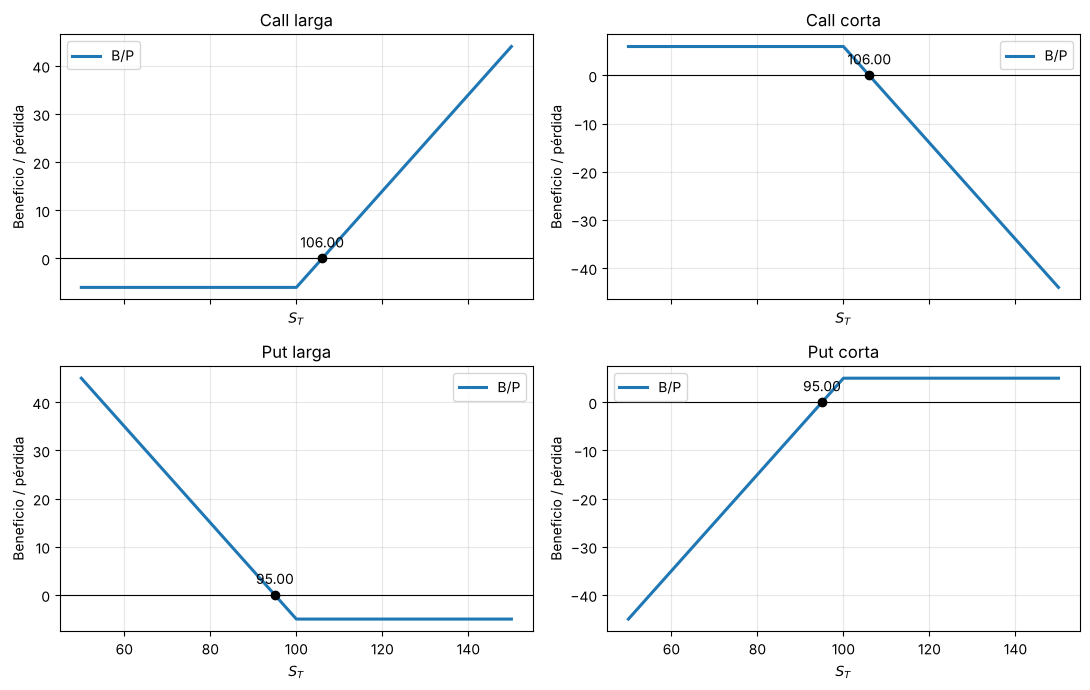

In [2]:
from mvdc import payoffs as po

K, C, P = 100, 6, 5
ST = np.linspace(50, 150, 501)

fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
casos = [("Call larga", po.long_call(ST, K, C)), ("Call corta", po.short_call(ST, K, C)),
         ("Put larga", po.long_put(ST, K, P)), ("Put corta", po.short_put(ST, K, P))]
for ax, (titulo, bp) in zip(axs.ravel(), casos):
    po.plot_strategy(ST, bp, ax=ax, title=titulo, label="B/P")
plt.tight_layout()

**Pregunta para el grupo.** ¿En qué intervalo de $S_T$ el tenedor de la call *ejerce aunque pierda dinero*?
(Zona crítica $[K, K+C]$; para la put, $[K-P, K]$.)

## 2. Terminología ITM / ATM / OTM y valor intrínseco (Ejercicio 2 del Tema 1)

In [3]:
S_t = 100
tabla = pd.DataFrame({"K": [90, 95, 100, 105, 110], "prima": [12, 10, 8, 6, 4]})
tabla["clasificación"] = [po.moneyness(S_t, k) for k in tabla.K]
tabla["VI"] = [po.intrinsic_value(S_t, k) for k in tabla.K]
tabla["VE"] = tabla.prima - tabla.VI
tabla

,K,prima,clasificación,VI,VE
0,90,12,ITM,10.0,2.0
1,95,10,ITM,5.0,5.0
2,100,8,ATM,0.0,8.0
3,105,6,OTM,0.0,6.0
4,110,4,OTM,0.0,4.0


## 3. Futuros y estrategias sintéticas (Tema 2)

Se combinan, sobre el **mismo subyacente, mismo K y mismo T**, un futuro y una opción.
La relación que guía todo el tema es

$$\text{Call} - \text{Put} = \text{Futuro}.$$

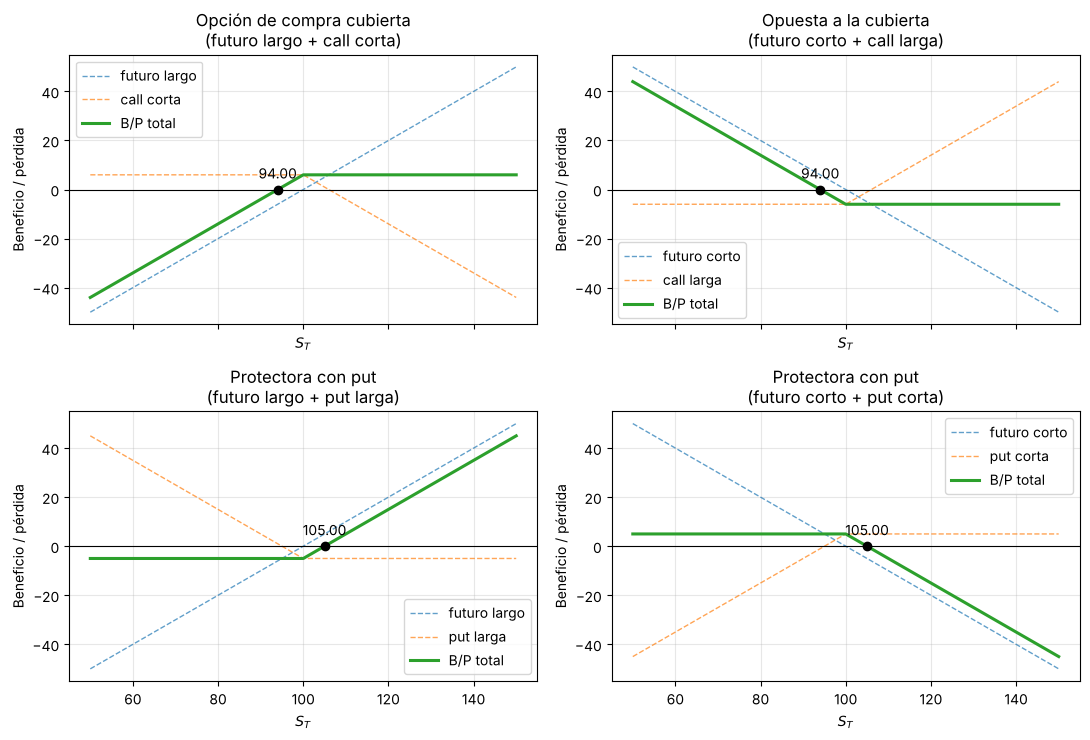

In [4]:
estrategias = {
    "Opción de compra cubierta\n(futuro largo + call corta)":
        [{"tipo": "future", "posicion": +1, "K": K}, {"tipo": "call", "posicion": -1, "K": K, "prima": C}],
    "Opuesta a la cubierta\n(futuro corto + call larga)":
        [{"tipo": "future", "posicion": -1, "K": K}, {"tipo": "call", "posicion": +1, "K": K, "prima": C}],
    "Protectora con put\n(futuro largo + put larga)":
        [{"tipo": "future", "posicion": +1, "K": K}, {"tipo": "put", "posicion": +1, "K": K, "prima": P}],
    "Protectora con put\n(futuro corto + put corta)":
        [{"tipo": "future", "posicion": -1, "K": K}, {"tipo": "put", "posicion": -1, "K": K, "prima": P}],
}
fig, axs = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
for ax, (titulo, legs) in zip(axs.ravel(), estrategias.items()):
    nombre = {("future", 1): "futuro largo", ("future", -1): "futuro corto", ("call", 1): "call larga",
              ("call", -1): "call corta", ("put", 1): "put larga", ("put", -1): "put corta"}
    comps = {nombre[(l["tipo"], l["posicion"])]: po.strategy(ST, [l]) for l in legs}
    po.plot_strategy(ST, po.strategy(ST, legs), ax=ax, title=titulo, components=comps)
plt.tight_layout()

**Comprobación numérica** de las equivalencias deducidas en el tema (en pay-off, sin primas):

In [5]:
fut = po.long_future(ST, K)
callp, putp = po.call_payoff(ST, K), po.put_payoff(ST, K)
print("Futuro − Call = −Put :", np.allclose(fut - callp, -putp))
print("Futuro + Put  =  Call:", np.allclose(fut + putp, callp))
print("−Futuro + Call =  Put:", np.allclose(-fut + callp, putp))

Futuro − Call = −Put : True
Futuro + Put  =  Call: True
−Futuro + Call =  Put: True


## 4. Ejercicio en clase (10 min)

Un inversor compra una call con $K_1 = 95$ (prima 8) y vende una call con $K_2 = 110$ (prima 2)
— un *bull call spread*.

1. Escribe la expresión de B/P total a trozos.
2. Grafícala con `po.strategy` y localiza el punto de equilibrio.
3. ¿Cuál es la pérdida máxima? ¿Y la ganancia máxima? ¿Qué visión del mercado refleja?

In [6]:
# Tu código aquí
legs = [
    # {"tipo": "call", "posicion": +1, "K": 95, "prima": 8},
    # ...
]

## 5. Antes de la próxima sesión

- Microtests 1.1–1.3 y 2.1–2.3 (fecha límite común: **10/01/2027 23:59**).
- La **Actividad 1** se presenta en la Clase 2: repasa los B/P de call y put larga.